# **4. Phân tích SHAP**

## **4.1 Setup - Load model, data, các hàm SHAP**

In [1]:
# Import môi trường
import seaborn as sns
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
import warnings
import sys
warnings.filterwarnings('ignore')

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Thêm src vào path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [3]:
# 1. Tìm project_root (chứa folder 'src')
current = Path.cwd().resolve()
project_root = next((p for p in [current, *current.parents] if (p / "src").exists()), None)
if project_root is None:
    raise FileNotFoundError("Không tìm thấy thư mục 'src'")
sys.path.insert(0, str(project_root))
print("project_root =", project_root)

project_root = D:\Python\AIN701_Group_04\demo


In [4]:
# 2. Load model đã train (tự tìm, không cần biết chính xác path)
model_path = project_root / 'data' / 'models' / 'lightgbm.pkl'  # kiểm tra đúng path em đã lưu lúc trước
best_model = joblib.load(model_path)
print("Đã load model:", type(best_model).__name__)

Đã load model: LGBMClassifier


In [6]:
# 3. Load data đã xử lý
processed_dir = project_root / 'data' / 'processed'
X_train = pd.read_pickle(processed_dir / 'X_train.pkl')
X_test = pd.read_pickle(processed_dir / 'X_test.pkl')
y_train = pd.read_pickle(processed_dir / 'y_train.pkl')
y_test = pd.read_pickle(processed_dir / 'y_test.pkl')
print("X_train:", X_train.shape, " X_test:", X_test.shape)

X_train: (204277, 24)  X_test: (51070, 24)


In [7]:
# 4. Import hàm SHAP
from src.models.shap_analysis import (
    get_explainer, compute_shap_values, plot_global_summary, plot_global_bar,
    get_rejected_cases, plot_local_waterfall, get_top_features_for_case
)
from src.models.predict_model import load_preprocessor_and_model, preprocess_single_input, predict_loan

THRESHOLD = 0.176  # đã chốt ở bước trước
figures_dir = project_root / 'src' / 'reports' / 'figures'

## **4.2 Global Explanation — Feature Importance tổng thể**

Đã tạo SHAP Explainer cho LightGBM model


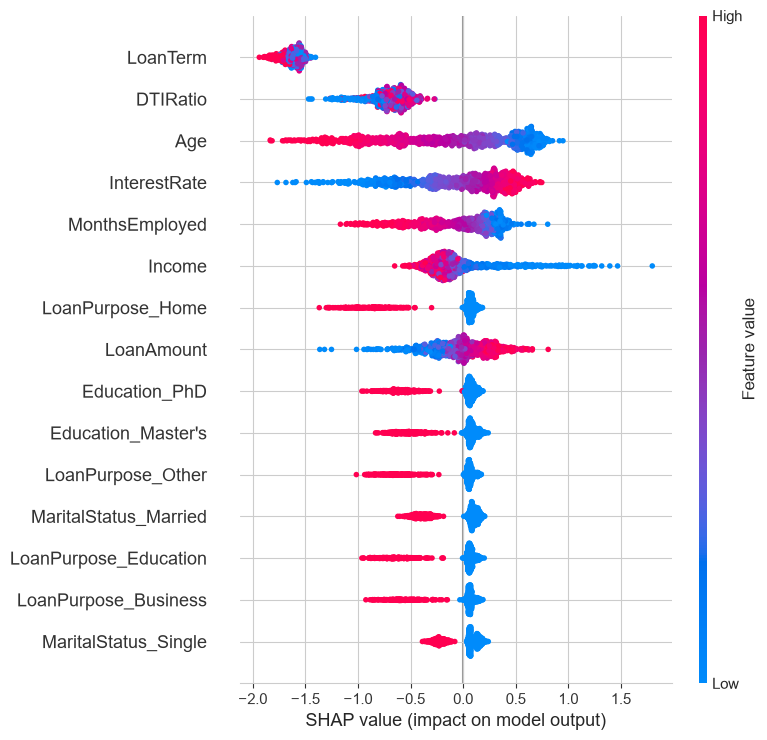

In [8]:
explainer = shap.TreeExplainer(best_model)
print("Đã tạo SHAP Explainer cho LightGBM model")

# Tính SHAP values cho 1000 mẫu ngẫu nhiên từ test set (đủ đại diện, nhanh hơn chạy hết 51k dòng)
X_sample, shap_values = compute_shap_values(explainer, X_test, sample_size=1000)

plot_global_summary(shap_values, X_sample, save_path=figures_dir / 'shap_summary.png')

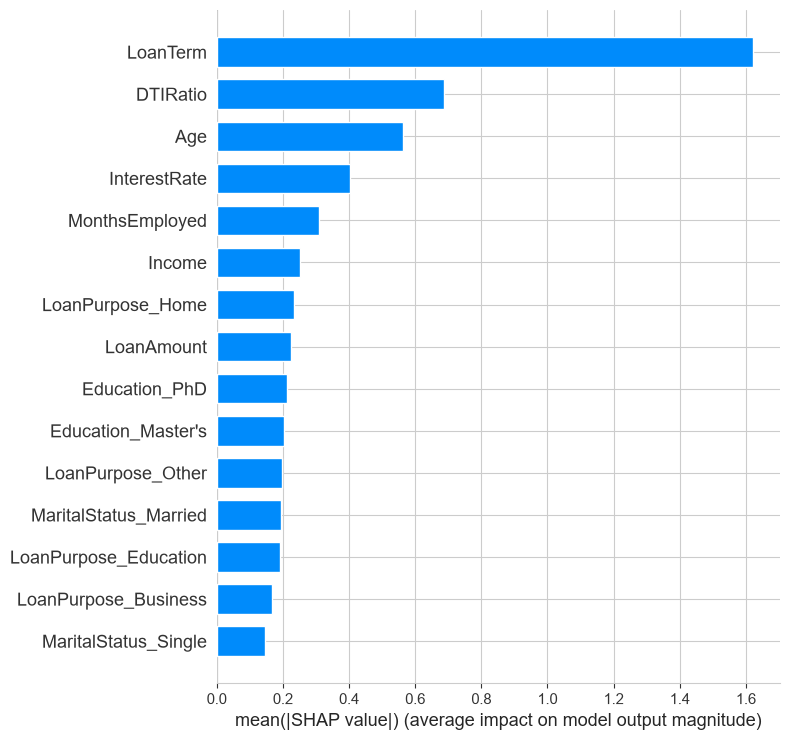

In [9]:
plot_global_bar(shap_values, X_sample, save_path=figures_dir / 'shap_importance_bar.png')

## **4.3 Local Explanation — Case bị từ chối thực tế trong tập test**

Số case bị từ chối trong mẫu 1000: 318


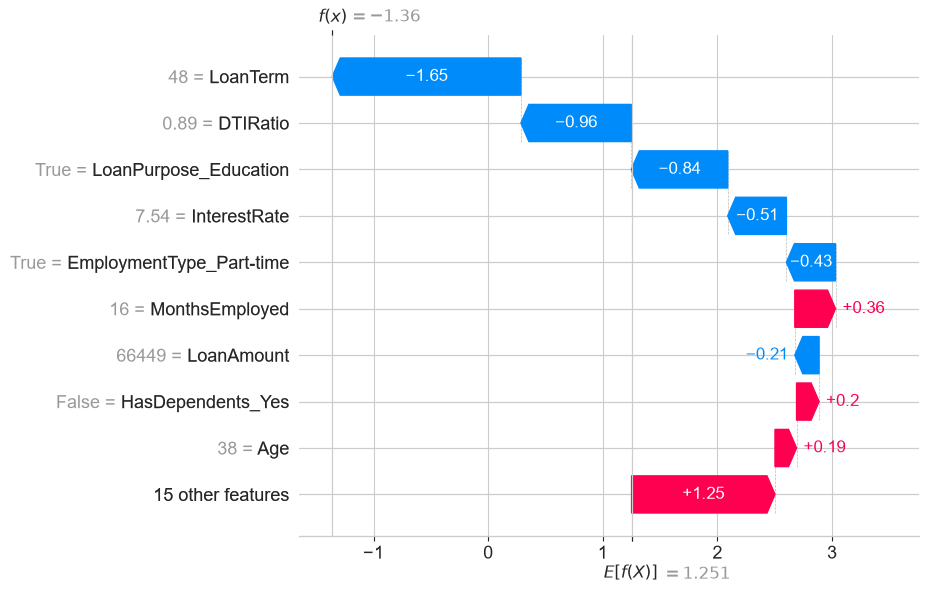

In [10]:
# Lấy các case bị model dự đoán "từ chối" (Default=1) theo threshold đã chốt, trong X_sample
rejected_idx, proba = get_rejected_cases(best_model, X_sample, THRESHOLD)
print(f"Số case bị từ chối trong mẫu {len(X_sample)}: {len(rejected_idx)}")

case_idx = rejected_idx[0]
plot_local_waterfall(explainer, shap_values, X_sample, case_idx,
                      save_path=figures_dir / 'shap_waterfall_example.png')

In [11]:
top_features = get_top_features_for_case(shap_values, X_sample, case_idx)
print(f"Xác suất default của case này: {proba[case_idx]:.4f}")
print(top_features)

Xác suất default của case này: 0.2042
                    feature value  shap_value
0                  LoanTerm    48   -1.645649
1                  DTIRatio  0.89   -0.963384
2     LoanPurpose_Education  True   -0.840603
3              InterestRate  7.54   -0.512089
4  EmploymentType_Part-time  True   -0.428346


In [12]:
# 1. Load model và feature names
model, preprocessing_info, feature_names = load_preprocessor_and_model()

# 2. Input test
raw_input = {
    'Age': 19, 
    'Income': 30000, 
    'LoanAmount': 200000, 
    'CreditScore': 450,
    'MonthsEmployed': 3, 
    'NumCreditLines': 5, 
    'InterestRate': 22.5, 
    'LoanTerm': 60,
    'DTIRatio': 0.85, 
    'Education': 'High School', 
    'EmploymentType': 'Unemployed',
    'MaritalStatus': 'Single', 
    'HasMortgage': 'No', 
    'HasDependents': 'No',
    'LoanPurpose': 'Business', 
    'HasCoSigner': 'No'
}

# 3. Dự đoán (dùng hàm chính)
result, X_input = predict_loan(raw_input)

print("Kết quả dự đoán:")
print(f"   Status: {result['status']}")
print(f"   Xác suất Default: {result['probability_default']:.4f}")

# 4. SHAP cho case này
explainer = shap.TreeExplainer(model)
shap_values_single = explainer.shap_values(X_input)

if isinstance(shap_values_single, list):
    shap_values = shap_values_single[1]   # class 1 = Default
    base_value = explainer.expected_value[1]
else:
    shap_values = shap_values_single
    base_value = explainer.expected_value

# 5. Top features
def get_top_features_for_case(shap_vals, X_input, idx=0, top_n=10):
    vals = shap_vals[idx] if len(shap_vals.shape) > 1 else shap_vals
    importance = pd.DataFrame({
        'Feature': X_input.columns,
        'SHAP Value': vals
    })
    importance['Abs_SHAP'] = importance['SHAP Value'].abs()
    return importance.sort_values('Abs_SHAP', ascending=False).head(top_n)

top_features = get_top_features_for_case(shap_values_single, X_input)
print("\nTop Features ảnh hưởng đến quyết định:")
print(top_features)

Loaded LightGBM model successfully!
Loaded LightGBM model successfully!
Kết quả dự đoán:
   Status: Rủi ro cao (Default)
   Xác suất Default: 0.9391

Top Features ảnh hưởng đến quyết định:
              Feature  SHAP Value  Abs_SHAP
7            LoanTerm   -1.664123  1.664123
0                 Age    0.669754  0.669754
6        InterestRate    0.568239  0.568239
8            DTIRatio   -0.527927  0.527927
5      NumCreditLines   -0.430339  0.430339
1              Income    0.413165  0.413165
4      MonthsEmployed    0.404709  0.404709
2          LoanAmount    0.325670  0.325670
23    HasCoSigner_Yes    0.172499  0.172499
18  HasDependents_Yes    0.137983  0.137983


In [ ]:
plot_global_summary(shap_values_single, X_sample, save_path=figures_dir / 'shap_summary_case.png')